In [1]:
##import libraries
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import r2_score
from prophet import Prophet
import time
from chronos import ChronosBoltPipeline
import matplotlib.dates as mdates
import numpy as np

c:\Users\shrey\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Took help from Gemini, ChatGPT, and CoPilot to design the trading strategies and implement the XGBOOST, TimesFM2.5, Chronos Bolt, and Prophet Algorithms for my specific crypto dogrcoin

In [2]:
dogecoin_data = yf.download('DOGE-USD', period="2y", interval="1h")

[*********************100%***********************]  1 of 1 completed


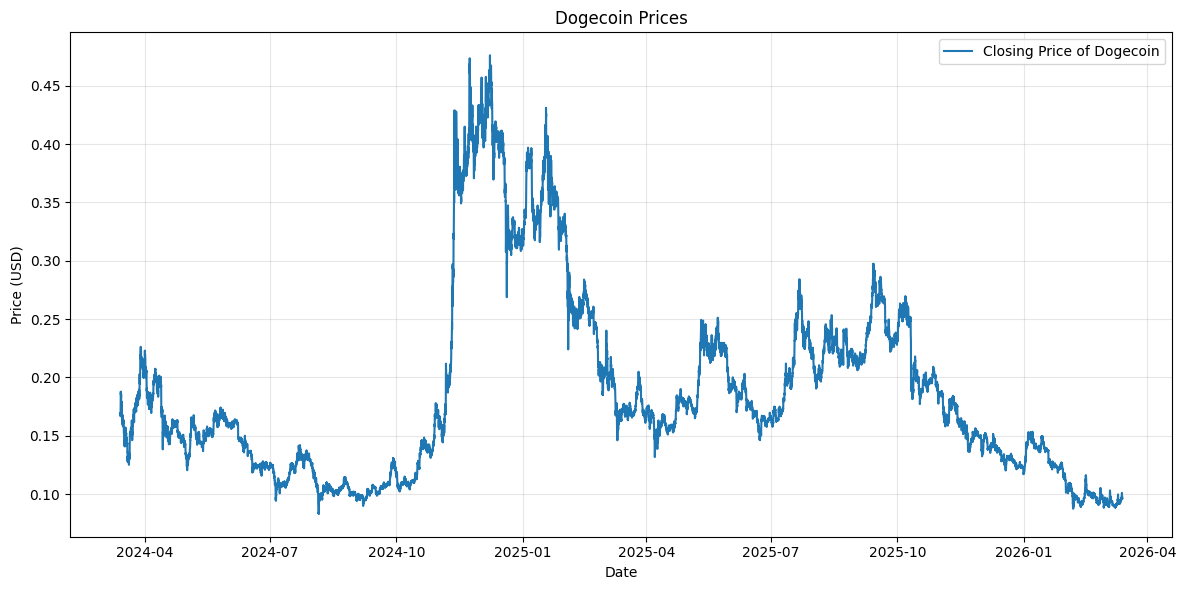

In [3]:
##plot the closing price of dogecoin
plt.figure(figsize=(12,6))
plt.plot(dogecoin_data['Close'], label='Closing Price of Dogecoin')
plt.title('Dogecoin Prices')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()

<Figure size 1200x600 with 0 Axes>

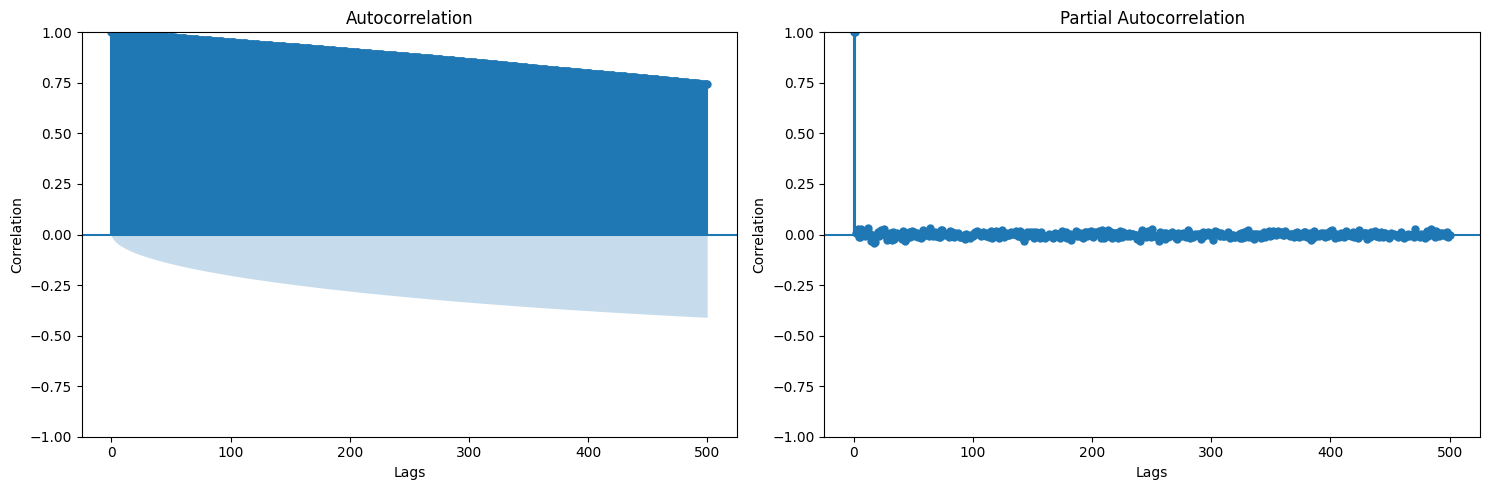

In [4]:
##plot the ACF and PACF of the closing price vs bitcoin
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize=(12,6))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(dogecoin_data['Close'], lags=500, ax=ax1)
plot_pacf(dogecoin_data['Close'], lags=500, ax=ax2)
ax1.set_xlabel('Lags')
ax1.set_ylabel('Correlation')
ax2.set_xlabel('Lags')
ax2.set_ylabel('Correlation')
plt.tight_layout()
plt.show()

In [5]:
##perform ADF test to check for stationarity
from statsmodels.tsa.stattools import adfuller
adf_test = adfuller(dogecoin_data['Close'])
print("ADF Statistic:", adf_test[0])
print("p-value:", adf_test[1])
print("Critical Values:", adf_test[4])

ADF Statistic: -1.9901180788585444
p-value: 0.29092271541012305
Critical Values: {'1%': np.float64(-3.430724950558707), '5%': np.float64(-2.861705713630974), '10%': np.float64(-2.5668582050701607)}


In [6]:
##Perform KPSS test to check for stationarity
from statsmodels.tsa.stattools import kpss
kpss_test = kpss(dogecoin_data['Close'], regression='c')
print("KPSS Statistic:", kpss_test[0])
print("p-value:", kpss_test[1])
print("Critical Values:", kpss_test[3])

KPSS Statistic: 2.186789674537821
p-value: 0.01
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\shrey\AppData\Local\Temp\ipykernel_15528\3675477603.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(dogecoin_data['Close'], regression='c')


In [7]:
import os
os.environ['STAN_NUM_THREADS'] = '1'

In [8]:
# ---------------------------------------------------------
# MODEL: CHRONOS BOLT
# ---------------------------------------------------------
# 1. PREPARE DATA
# ---------------------------------------------------------
series_chronos = dogecoin_data.reset_index()
if isinstance(series_chronos.columns, pd.MultiIndex):
    series_chronos.columns = series_chronos.columns.get_level_values(0)

series_chronos = pd.DataFrame({
    'ds': series_chronos['Datetime'].dt.tz_localize(None),
    'y': np.log(series_chronos['Close'].astype(float).values.flatten())
})

# ---------------------------------------------------------
# 2. MODEL INITIALIZATION
# ---------------------------------------------------------
pipeline = ChronosBoltPipeline.from_pretrained(
    "amazon/chronos-bolt-tiny",
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

# ---------------------------------------------------------
# 3. PARAMETER OPTIMIZATION
# ---------------------------------------------------------
def find_best_hourly_params_chronos(df):
    best_mae = float('inf')
    best_params = (24, 720) 
    
    full_tensor = torch.tensor(df['y'].values)

    print("Searching for optimal hourly parameters for Chronos...")
    for h in [24, 48, 72]:        
        for c in [336, 672, 1008]: 
            test_preds, test_acts = [], []
            for w in range(3):
                end_idx = len(df) - (w * h)
                test_start = end_idx - h
                train_start = test_start - c
                if train_start < 0: break
                
                context = full_tensor[train_start:test_start]
                forecast = pipeline.predict(context, h)
                y_hat = np.median(forecast[0].numpy(), axis=0)
                
                test_preds.append(y_hat)
                test_acts.append(df.iloc[test_start:end_idx]['y'].values)
            
            if len(test_preds) > 0:
                combined_preds = np.concatenate(test_preds)
                combined_acts = np.concatenate(test_acts)
                mae = np.mean(np.abs(combined_preds - combined_acts))
                if mae < best_mae:
                    best_mae = mae
                    best_params = (h, c)
    return best_params

horizon_chronos, context_chronos = find_best_hourly_params_chronos(series_chronos)
steps_chronos = 20
print(f"Optimal Found: Horizon={horizon_chronos}h, Context={context_chronos}h")

# ---------------------------------------------------------
# 4. ROLLING BACKTEST
# ---------------------------------------------------------
final_preds_chronos, final_acts_chronos = [], []
full_tensor_chronos = torch.tensor(series_chronos['y'].values)

print(f"Executing Chronos Bolt final backtest across {steps_chronos} windows...")

for w in range(steps_chronos):
    end_idx = len(series_chronos) - (w * horizon_chronos)
    test_start = end_idx - horizon_chronos
    train_start = test_start - context_chronos
    
    context_window = full_tensor_chronos[train_start:test_start]
    actual_segment = series_chronos.iloc[test_start:end_idx]['y'].values

    forecast = pipeline.predict(context_window, horizon_chronos)
    y_hat = np.median(forecast[0].numpy(), axis=0)
    
    final_preds_chronos.append(y_hat)
    final_acts_chronos.append(actual_segment)

pred_chronos = np.concatenate(final_preds_chronos[::-1])
actual_chronos = np.concatenate(final_acts_chronos[::-1])

# ---------------------------------------------------------
# 5. STRATEGY VS. BASELINE SIMULATION
# ---------------------------------------------------------
initial_investment = 200000
prices_pred_chronos = np.exp(pred_chronos)
prices_act_chronos = np.exp(actual_chronos)

portfolio_chronos = [initial_investment]
for i in range(1, len(prices_pred_chronos)):
    hourly_ret = (prices_act_chronos[i] - prices_act_chronos[i-1]) / prices_act_chronos[i-1]
    if prices_pred_chronos[i] > prices_act_chronos[i-1]:
        portfolio_chronos.append(portfolio_chronos[-1] * (1 + hourly_ret))
    else:
        portfolio_chronos.append(portfolio_chronos[-1]) 

units_held_chronos = initial_investment / prices_act_chronos[0]
baseline_chronos = units_held_chronos * prices_act_chronos

# ---------------------------------------------------------
# 6. RESULTS
# ---------------------------------------------------------
print(f"\n--- CHRONOS BOLT FINAL RESULTS ---")
print(f"MAE: {np.mean(np.abs(pred_chronos - actual_chronos)):.4f}")
print(f"R2 Score: {r2_score(actual_chronos, pred_chronos):.4f}")
print(f"Forecast Strategy Final: ${portfolio_chronos[-1]:,.2f}")
print(f"Baseline (Buy & Hold) Final: ${baseline_chronos[-1]:,.2f}")
print(f"Loss/Gain vs Baseline: {((portfolio_chronos[-1] - baseline_chronos[-1]) / baseline_chronos[-1]) * 100:+.2f}%")

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


Searching for optimal hourly parameters for Chronos...


c:\Users\shrey\AppData\Local\Programs\Python\Python313\Lib\site-packages\chronos\chronos_bolt.py:509: UserWarning: We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
  warnings.warn(msg)


Optimal Found: Horizon=24h, Context=1008h
Executing Chronos Bolt final backtest across 20 windows...

--- CHRONOS BOLT FINAL RESULTS ---
MAE: 0.0235
R2 Score: 0.0074
Forecast Strategy Final: $177,467.42
Baseline (Buy & Hold) Final: $194,063.53
Loss/Gain vs Baseline: -8.55%


In [9]:
# ---------------------------------------------------------
# MODEL: TIMESFM 2.5
# ---------------------------------------------------------
import timesfm

# ---------------------------------------------------------
# 1. PREPARE DATA
# ---------------------------------------------------------
series_timesfm = dogecoin_data.reset_index()
if isinstance(series_timesfm.columns, pd.MultiIndex):
    series_timesfm.columns = series_timesfm.columns.get_level_values(0)

series_timesfm = pd.DataFrame({
    'ds': series_timesfm['Datetime'].dt.tz_localize(None),
    'y': np.log(series_timesfm['Close'].astype(float).values.flatten())
})

# ---------------------------------------------------------
# 2. MODEL INITIALIZATION
# ---------------------------------------------------------
torch.set_float32_matmul_precision("high")

model_tfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

model_tfm.compile(timesfm.ForecastConfig(
    max_context=1024,
    max_horizon=168,
    normalize_inputs=True,
    use_continuous_quantile_head=True,
    fix_quantile_crossing=True
))

# ---------------------------------------------------------
# 3. ROLLING BACKTEST
# ---------------------------------------------------------
steps_tfm = 20
horizon_tfm = 24
context_tfm = 1024 

final_preds_tfm, final_acts_tfm = [], []

print(f"Executing TimesFM 2.5 backtest across {steps_tfm} windows...")

for w in range(steps_tfm):
    end_idx = len(series_timesfm) - (w * horizon_tfm)
    test_start = end_idx - horizon_tfm
    train_start = test_start - context_tfm
    
    if train_start < 0: continue

    historical_context = [series_timesfm.iloc[train_start:test_start]['y'].values]
    
    point_forecast_tfm, _ = model_tfm.forecast(
        horizon=horizon_tfm,
        inputs=historical_context
    )
    
    y_hat_tfm = point_forecast_tfm[0] 
    
    final_preds_tfm.append(y_hat_tfm)
    final_acts_tfm.append(series_timesfm.iloc[test_start:end_idx]['y'].values)

pred_tfm = np.concatenate(final_preds_tfm[::-1])
actual_tfm = np.concatenate(final_acts_tfm[::-1])

# ---------------------------------------------------------
# 4. STRATEGY VS. BASELINE SIMULATION
# ---------------------------------------------------------
initial_investment = 200000
prices_pred_tfm, prices_act_tfm = np.exp(pred_tfm), np.exp(actual_tfm)

portfolio_tfm = [initial_investment]
for i in range(1, len(prices_pred_tfm)):
    hourly_ret = (prices_act_tfm[i] - prices_act_tfm[i-1]) / prices_act_tfm[i-1]
    if prices_pred_tfm[i] > prices_act_tfm[i-1]: # Adjusted for direct logic
        portfolio_tfm.append(portfolio_tfm[-1] * (1 + hourly_ret))
    else:
        portfolio_tfm.append(portfolio_tfm[-1]) 

# Calculate Baseline (Buy & Hold)
units_held_tfm = initial_investment / prices_act_tfm[0]
baseline_tfm = units_held_tfm * prices_act_tfm

# ---------------------------------------------------------
# 5. RESULTS
# ---------------------------------------------------------
print(f"\n--- TIMESFM 2.5 FINAL RESULTS ---")
print(f"MAE: {np.mean(np.abs(pred_tfm - actual_tfm)):.4f}")
print(f"R2 Score: {r2_score(actual_tfm, pred_tfm):.4f}")
print(f"Forecast Strategy Final: ${portfolio_tfm[-1]:,.2f}")
print(f"Baseline (Buy & Hold) Final: ${baseline_tfm[-1]:,.2f}")
print(f"Loss/Gain vs Baseline: {((portfolio_tfm[-1] - baseline_tfm[-1]) / baseline_tfm[-1]) * 100:+.2f}%")

Downloaded.
Executing TimesFM 2.5 backtest across 20 windows...

--- TIMESFM 2.5 FINAL RESULTS ---
MAE: 0.0229
R2 Score: 0.0447
Forecast Strategy Final: $182,354.83
Baseline (Buy & Hold) Final: $194,063.53
Loss/Gain vs Baseline: -6.03%


In [10]:
# ---------------------------------------------------------
# MODEL: PROPHET
# ---------------------------------------------------------
# 1. PREPARE DATA
# ---------------------------------------------------------
series_prophet = dogecoin_data.reset_index()
if isinstance(series_prophet.columns, pd.MultiIndex):
    series_prophet.columns = series_prophet.columns.get_level_values(0)

series_prophet = pd.DataFrame({
    'ds': series_prophet['Datetime'].dt.tz_localize(None),
    'y': np.log(series_prophet['Close'].astype(float).values.flatten())
})

# ---------------------------------------------------------
# 2. PARAMETER OPTIMIZATION
# ---------------------------------------------------------
def find_best_hourly_params_prophet(df):
    best_mae = float('inf')
    best_params = (24, 720) 
    
    print("Searching for optimal hourly parameters for Prophet...")
    for h in [24, 48, 72]:        
        for c in [336, 672, 1008]: 
            test_preds, test_acts = [], []
            for w in range(3):
                end_idx = len(df) - (w * h)
                test_start = end_idx - h
                train_start = test_start - c
                
                if train_start < 0: break
                
                train_df = df.iloc[train_start:test_start]
                
                model = Prophet(changepoint_prior_scale=0.03, 
                                daily_seasonality=True, 
                                weekly_seasonality=True, 
                                yearly_seasonality=False)
                model.fit(train_df)
                
                future = model.make_future_dataframe(periods=h, freq='h')
                forecast = model.predict(future)
                
                test_preds.append(forecast['yhat'].iloc[-h:].values)
                test_acts.append(df.iloc[test_start:end_idx]['y'].values)
            
            if len(test_preds) > 0:
                mae = np.mean(np.abs(np.concatenate(test_preds) - np.concatenate(test_acts)))
                if mae < best_mae:
                    best_mae = mae
                    best_params = (h, c)
    return best_params

horizon_prophet, context_length_prophet = find_best_hourly_params_prophet(series_prophet)
steps_prophet = 20 # Number of windows for the final backtest
print(f"Optimal Found: Horizon={horizon_prophet}h, Context={context_length_prophet}h")

# ---------------------------------------------------------
# 3. ROLLING BACKTEST
# ---------------------------------------------------------
final_preds_prophet, final_acts_prophet = [], []
print(f"Executing final Prophet backtest across {steps_prophet} windows...")

for w in range(steps_prophet):
    end_idx = len(series_prophet) - (w * horizon_prophet)
    test_start = end_idx - horizon_prophet
    train_start = test_start - context_length_prophet
    
    if train_start < 0: continue
    
    train_df_step = series_prophet.iloc[train_start:test_start]
    actual_vals_step = series_prophet.iloc[test_start:end_idx]['y'].values

    model = Prophet(changepoint_prior_scale=0.05, 
                    daily_seasonality=True, 
                    weekly_seasonality=True, 
                    yearly_seasonality=False)
    model.fit(train_df_step)
    
    future = model.make_future_dataframe(periods=horizon_prophet, freq='h')
    forecast = model.predict(future)
    
    final_preds_prophet.append(forecast['yhat'].iloc[-horizon_prophet:].values)
    final_acts_prophet.append(actual_vals_step)

pred_prophet = np.concatenate(final_preds_prophet[::-1])
actual_prophet = np.concatenate(final_acts_prophet[::-1])

# ---------------------------------------------------------
# 4. STRATEGY VS. BASELINE SIMULATION
# ---------------------------------------------------------
initial_investment = 200000
prices_pred_prophet = np.exp(pred_prophet)
prices_act_prophet = np.exp(actual_prophet)

portfolio_prophet = [initial_investment]
for i in range(1, len(prices_pred_prophet)):
    hourly_ret = (prices_act_prophet[i] - prices_act_prophet[i-1]) / prices_act_prophet[i-1]
    # Trade logic: Buy if model says price will go up, otherwise stay in cash
    if prices_pred_prophet[i] > prices_act_prophet[i-1]:
        portfolio_prophet.append(portfolio_prophet[-1] * (1 + hourly_ret))
    else:
        portfolio_prophet.append(portfolio_prophet[-1]) 

units_held_prophet = initial_investment / prices_act_prophet[0]
baseline_prophet = units_held_prophet * prices_act_prophet

# ---------------------------------------------------------
# 5. RESULTS
# ---------------------------------------------------------
print(f"\n--- PROPHET FINAL RESULTS ---")
print(f"MAE: {np.mean(np.abs(pred_prophet - actual_prophet)):.4f}")
print(f"R2 Score: {r2_score(actual_prophet, pred_prophet):.4f}")
print(f"Forecast Strategy Final: ${portfolio_prophet[-1]:,.2f}")
print(f"Baseline (Buy & Hold) Final: ${baseline_prophet[-1]:,.2f}")
print(f"Loss/Gain vs Baseline: {((portfolio_prophet[-1] - baseline_prophet[-1]) / baseline_prophet[-1]) * 100:+.2f}%")

Searching for optimal hourly parameters for Prophet...
Optimal Found: Horizon=72h, Context=1008h
Executing final Prophet backtest across 20 windows...

--- PROPHET FINAL RESULTS ---
MAE: 0.0480
R2 Score: 0.8012
Forecast Strategy Final: $177,864.33
Baseline (Buy & Hold) Final: $140,191.51
Loss/Gain vs Baseline: +26.87%


In [11]:
# ---------------------------------------------------------
# MODEL: XGBOOST
# ---------------------------------------------------------
from xgboost import XGBRegressor

# ---------------------------------------------------------
# 1. PREPARE DATA
# ---------------------------------------------------------
series_xgb = dogecoin_data.reset_index()
if isinstance(series_xgb.columns, pd.MultiIndex):
    series_xgb.columns = series_xgb.columns.get_level_values(0)

series_xgb = pd.DataFrame({
    'ds': series_xgb['Datetime'].dt.tz_localize(None),
    'y': np.log(series_xgb['Close'].astype(float).values.flatten())
})

# ---------------------------------------------------------
# 2. FEATURE ENGINEERING
# ---------------------------------------------------------
steps_xgb = 20
horizon_xgb = 24
context_xgb = 1008
lag_cols = [1, 2, 3, 6, 12, 24, 48, 72]
max_lag = max(lag_cols)

def make_xgb_features(df):
    feat = df.copy()
    for lag in lag_cols:
        feat[f'lag_{lag}'] = feat['y'].shift(lag)
    feat['roll_mean_24'] = feat['y'].shift(1).rolling(24).mean()
    feat['roll_std_24'] = feat['y'].shift(1).rolling(24).std()
    feat['roll_mean_72'] = feat['y'].shift(1).rolling(72).mean()
    feat['roll_std_72'] = feat['y'].shift(1).rolling(72).std()
    feat = feat.dropna().reset_index(drop=True)
    return feat

# ---------------------------------------------------------
# 3. ROLLING BACKTEST
# ---------------------------------------------------------
final_preds_xgb, final_acts_xgb = [], []

print(f"Executing XGBoost backtest across {steps_xgb} windows...")

for w in range(steps_xgb):
    end_idx = len(series_xgb) - (w * horizon_xgb)
    test_start = end_idx - horizon_xgb
    train_start = test_start - context_xgb

    if train_start < max_lag + 72:
        continue

    train_df_step = series_xgb.iloc[train_start:test_start].copy()
    train_feat = make_xgb_features(train_df_step)

    feature_cols = [c for c in train_feat.columns if c.startswith('lag_') or c.startswith('roll_')]
    X_train = train_feat[feature_cols]
    y_train = train_feat['y']

    model_xgb = XGBRegressor(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='reg:squarederror',
        random_state=42
    )
    model_xgb.fit(X_train, y_train)

    history_vals = list(train_df_step['y'].values)
    preds_step = []

    for _ in range(horizon_xgb):
        row = {}
        for lag in lag_cols:
            row[f'lag_{lag}'] = history_vals[-lag]
        row['roll_mean_24'] = float(np.mean(history_vals[-24:]))
        row['roll_std_24'] = float(np.std(history_vals[-24:]))
        row['roll_mean_72'] = float(np.mean(history_vals[-72:]))
        row['roll_std_72'] = float(np.std(history_vals[-72:]))

        X_next = pd.DataFrame([row])
        y_hat_next = model_xgb.predict(X_next)[0]
        preds_step.append(y_hat_next)
        history_vals.append(y_hat_next)

    final_preds_xgb.append(np.array(preds_step))
    final_acts_xgb.append(series_xgb.iloc[test_start:end_idx]['y'].values)

pred_xgb = np.concatenate(final_preds_xgb[::-1])
actual_xgb = np.concatenate(final_acts_xgb[::-1])

# ---------------------------------------------------------
# 4. STRATEGY VS. BASELINE SIMULATION
# ---------------------------------------------------------
initial_investment = 200000
prices_pred_xgb = np.exp(pred_xgb)
prices_act_xgb = np.exp(actual_xgb)

portfolio_xgb = [initial_investment]
for i in range(1, len(prices_pred_xgb)):
    hourly_ret = (prices_act_xgb[i] - prices_act_xgb[i-1]) / prices_act_xgb[i-1]
    if prices_pred_xgb[i] > prices_act_xgb[i-1]:
        portfolio_xgb.append(portfolio_xgb[-1] * (1 + hourly_ret))
    else:
        portfolio_xgb.append(portfolio_xgb[-1])

units_held_xgb = initial_investment / prices_act_xgb[0]
baseline_xgb = units_held_xgb * prices_act_xgb

# ---------------------------------------------------------
# 5. RESULTS
# ---------------------------------------------------------
print(f"\n--- XGBOOST FINAL RESULTS ---")
print(f"MAE: {np.mean(np.abs(pred_xgb - actual_xgb)):.4f}")
print(f"R2 Score: {r2_score(actual_xgb, pred_xgb):.4f}")
print(f"Forecast Strategy Final: ${portfolio_xgb[-1]:,.2f}")
print(f"Baseline (Buy & Hold) Final: ${baseline_xgb[-1]:,.2f}")
print(f"Loss/Gain vs Baseline: {((portfolio_xgb[-1] - baseline_xgb[-1]) / baseline_xgb[-1]) * 100:+.2f}%")

Executing XGBoost backtest across 20 windows...

--- XGBOOST FINAL RESULTS ---
MAE: 0.0252
R2 Score: -0.1553
Forecast Strategy Final: $201,203.24
Baseline (Buy & Hold) Final: $194,063.53
Loss/Gain vs Baseline: +3.68%


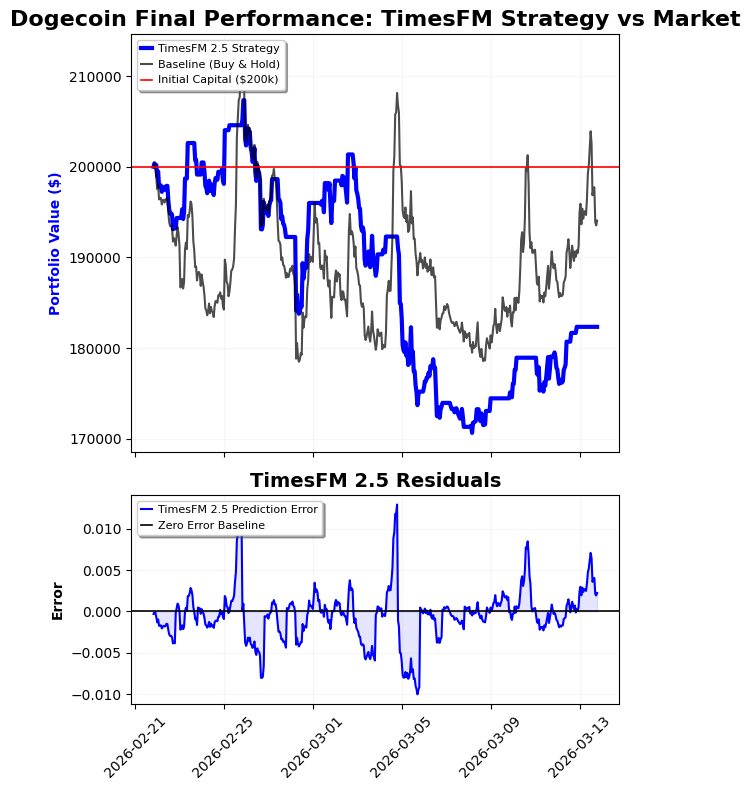

In [12]:
residuals_tfm = np.exp(actual_tfm) - np.exp(pred_tfm)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(series_timesfm['ds'][-len(portfolio_tfm):], portfolio_tfm, 
         label='TimesFM 2.5 Strategy', color='blue', lw=3)
ax1.plot(series_timesfm['ds'][-len(baseline_tfm):], baseline_tfm, 
         label='Baseline (Buy & Hold)', color='black', lw=1.5, alpha=0.7)
ax1.axhline(y=initial_investment, color='red', lw=1.2, label='Initial Capital ($200k)')

ax1.set_title('Dogecoin Final Performance: TimesFM Strategy vs Market', fontsize=16, fontweight='bold')
ax1.set_ylabel('Portfolio Value ($)', color='blue', fontweight='bold')
ax1.legend(loc='upper left', frameon=True, shadow=True, 
           prop={'size': 8}, handlelength=1.0, handletextpad=0.5, borderpad=0.4)
ax1.grid(True, linestyle='-', alpha=0.1)

ax2.plot(series_timesfm['ds'][-len(residuals_tfm):], residuals_tfm, 
         color='blue', lw=1.5, label='TimesFM 2.5 Prediction Error')
ax2.axhline(y=0, color='black', lw=1.2, label='Zero Error Baseline')
ax2.fill_between(series_timesfm['ds'][-len(residuals_tfm):], 0, residuals_tfm, 
                 color='blue', alpha=0.1)

ax2.set_title('TimesFM 2.5 Residuals', fontsize=14, fontweight='bold')
ax2.set_ylabel('Error', fontweight='bold')
ax2.legend(loc='upper left', frameon=True, shadow=True, 
           prop={'size': 8}, handlelength=1.0, handletextpad=0.5, borderpad=0.4)
ax2.grid(True, linestyle='-', alpha=0.1)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

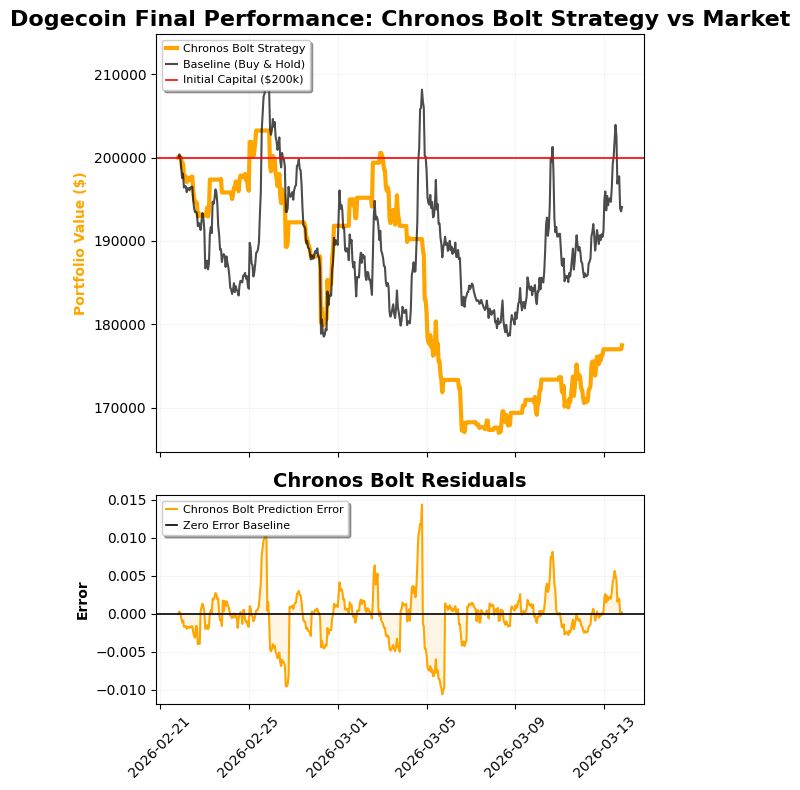

In [13]:
residuals_chronos = np.exp(actual_chronos) - np.exp(pred_chronos)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(series_chronos['ds'][-len(portfolio_chronos):], portfolio_chronos, 
         label='Chronos Bolt Strategy', color='orange', lw=3)
ax1.plot(series_chronos['ds'][-len(baseline_chronos):], baseline_chronos, 
         label='Baseline (Buy & Hold)', color='black', lw=1.5, alpha=0.7)
ax1.axhline(y=initial_investment, color='red', lw=1.2, label='Initial Capital ($200k)')

ax1.set_title('Dogecoin Final Performance: Chronos Bolt Strategy vs Market', fontsize=16, fontweight='bold')
ax1.set_ylabel('Portfolio Value ($)', color='orange', fontweight='bold')
ax1.legend(loc='upper left', frameon=True, shadow=True, 
           prop={'size': 8}, handlelength=1.0, handletextpad=0.5, borderpad=0.4)
ax1.grid(True, linestyle='-', alpha=0.1)

ax2.plot(series_chronos['ds'][-len(residuals_chronos):], residuals_chronos, 
         color='orange', lw=1.5, label='Chronos Bolt Prediction Error')
ax2.axhline(y=0, color='black', lw=1.2, label='Zero Error Baseline')
ax2.fill_between(series_chronos['ds'][-len(residuals_chronos):], 0, residuals_chronos, 
                 color='orange', alpha=0.1)

ax2.set_title('Chronos Bolt Residuals', fontsize=14, fontweight='bold')
ax2.set_ylabel('Error', fontweight='bold')
ax2.legend(loc='upper left', frameon=True, shadow=True, 
           prop={'size': 8}, handlelength=1.0, handletextpad=0.5, borderpad=0.4)
ax2.grid(True, linestyle='-', alpha=0.1)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

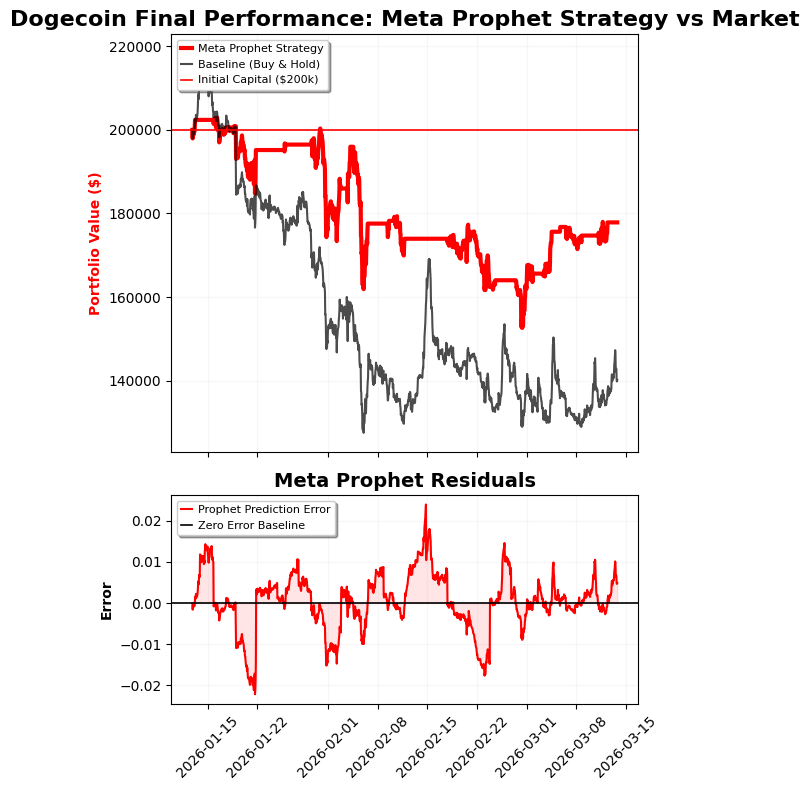

In [14]:
residuals_prophet = np.exp(actual_prophet) - np.exp(pred_prophet)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(series_prophet['ds'][-len(portfolio_prophet):], portfolio_prophet, 
         label='Meta Prophet Strategy', color='red', lw=3)
ax1.plot(series_prophet['ds'][-len(baseline_prophet):], baseline_prophet, 
         label='Baseline (Buy & Hold)', color='black', lw=1.5, alpha=0.7)
ax1.axhline(y=initial_investment, color='red', lw=1.2, label='Initial Capital ($200k)')

ax1.set_title('Dogecoin Final Performance: Meta Prophet Strategy vs Market', fontsize=16, fontweight='bold')
ax1.set_ylabel('Portfolio Value ($)', color='red', fontweight='bold')


ax1.legend(loc='upper left', frameon=True, shadow=True, 
           prop={'size': 8},     
           handlelength=1.0,    
           handletextpad=0.5,    
           borderpad=0.4)       

ax1.grid(True, linestyle='-', alpha=0.1)

ax2.plot(series_prophet['ds'][-len(residuals_prophet):], residuals_prophet, 
         color='red', lw=1.5, label='Prophet Prediction Error')
ax2.axhline(y=0, color='black', lw=1.2, label='Zero Error Baseline')
ax2.fill_between(series_prophet['ds'][-len(residuals_prophet):], 0, residuals_prophet, 
                 color='red', alpha=0.1)

ax2.set_title('Meta Prophet Residuals', fontsize=14, fontweight='bold')
ax2.set_ylabel('Error', fontweight='bold')


ax2.legend(loc='upper left', frameon=True, shadow=True, 
           prop={'size': 8}, 
           handlelength=1.0, 
           handletextpad=0.5, 
           borderpad=0.4)

ax2.grid(True, linestyle='-', alpha=0.1)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

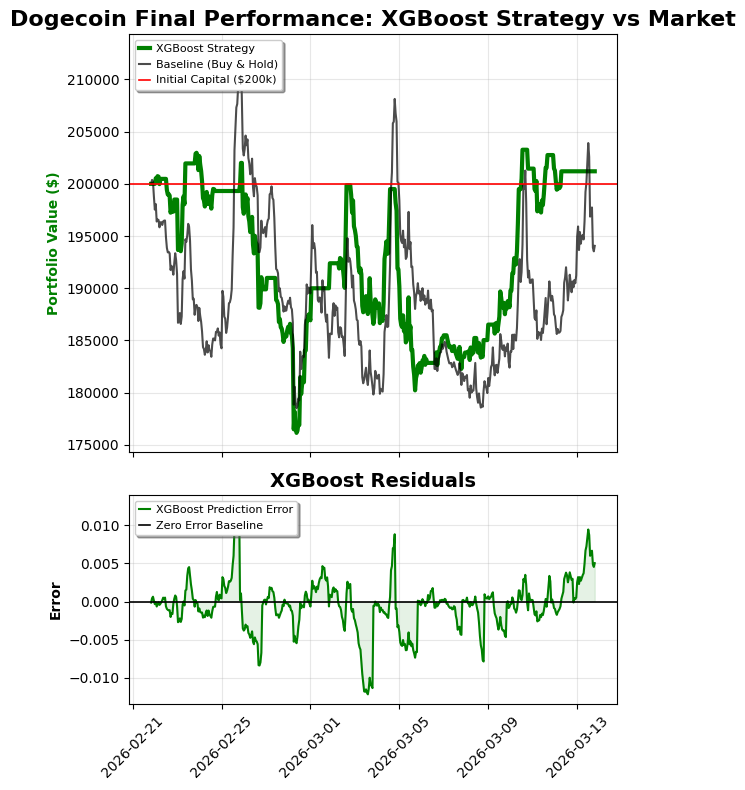

In [15]:
residuals_xgb = np.exp(actual_xgb) - np.exp(pred_xgb)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(series_xgb['ds'][-len(portfolio_xgb):], portfolio_xgb, 
         label='XGBoost Strategy', color='green', lw=3)
ax1.plot(series_xgb['ds'][-len(baseline_xgb):], baseline_xgb, 
         label='Baseline (Buy & Hold)', color='black', lw=1.5, alpha=0.7)
ax1.axhline(y=initial_investment, color='red', lw=1.2, label='Initial Capital ($200k)')

ax1.set_title('Dogecoin Final Performance: XGBoost Strategy vs Market', fontsize=16, fontweight='bold')
ax1.set_ylabel('Portfolio Value ($)', color='green', fontweight='bold')
ax1.legend(loc='upper left', frameon=True, shadow=True, 
           prop={'size': 8}, handlelength=1.0, handletextpad=0.5, borderpad=0.4)
ax1.grid(True, linestyle='-', alpha=0.3)

ax2.plot(series_xgb['ds'][-len(residuals_xgb):], residuals_xgb, 
         color='green', lw=1.5, label='XGBoost Prediction Error')
ax2.axhline(y=0, color='black', lw=1.2, label='Zero Error Baseline')
ax2.fill_between(series_xgb['ds'][-len(residuals_xgb):], 0, residuals_xgb, 
                 color='green', alpha=0.1)

ax2.set_title('XGBoost Residuals', fontsize=14, fontweight='bold')
ax2.set_ylabel('Error', fontweight='bold')
ax2.legend(loc='upper left', frameon=True, shadow=True, 
           prop={'size': 8}, handlelength=1.0, handletextpad=0.5, borderpad=0.4)
ax2.grid(True, linestyle='-', alpha=0.3)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [16]:
metrics_df = pd.DataFrame({
    'Model': ['Google TimesFM 2.5', 'Amazon Chronos Bolt', 'Meta Prophet', 'XGBoost'],
    'MAE': [
        np.mean(np.abs(pred_tfm - actual_tfm)),
        np.mean(np.abs(pred_chronos - actual_chronos)),
        np.mean(np.abs(pred_prophet - actual_prophet)),
        np.mean(np.abs(pred_xgb - actual_xgb))
    ],
    'R2 Score': [
        r2_score(actual_tfm, pred_tfm),
        r2_score(actual_chronos, pred_chronos),
        r2_score(actual_prophet, pred_prophet),
        r2_score(actual_xgb, pred_xgb)
    ],
    'Final Portfolio Value ($)': [
        portfolio_tfm[-1],
        portfolio_chronos[-1],
        portfolio_prophet[-1],
        portfolio_xgb[-1]
    ],
    'Baseline Final Value ($)': [
        baseline_tfm[-1],
        baseline_chronos[-1],
        baseline_prophet[-1],
        baseline_xgb[-1]
    ],
    'Net vs Baseline ($)': [
        portfolio_tfm[-1] - baseline_tfm[-1],
        portfolio_chronos[-1] - baseline_chronos[-1],
        portfolio_prophet[-1] - baseline_prophet[-1],
        portfolio_xgb[-1] - baseline_xgb[-1]
    ],
    'Net vs Baseline (%)': [
        ((portfolio_tfm[-1] - baseline_tfm[-1]) / baseline_tfm[-1]) * 100,
        ((portfolio_chronos[-1] - baseline_chronos[-1]) / baseline_chronos[-1]) * 100,
        ((portfolio_prophet[-1] - baseline_prophet[-1]) / baseline_prophet[-1]) * 100,
        ((portfolio_xgb[-1] - baseline_xgb[-1]) / baseline_xgb[-1]) * 100
    ],
    'Total ROI (%)': [
        ((portfolio_tfm[-1] - initial_investment) / initial_investment) * 100,
        ((portfolio_chronos[-1] - initial_investment) / initial_investment) * 100,
        ((portfolio_prophet[-1] - initial_investment) / initial_investment) * 100,

        ((portfolio_xgb[-1] - initial_investment) / initial_investment) * 100

    ]
})
    
metrics_df


,Model,MAE,R2 Score,Final Portfolio Value ($),Baseline Final Value ($),Net vs Baseline ($),Net vs Baseline (%),Total ROI (%)
0,Google TimesFM 2.5,0.022896,0.044670,182354.834735,194063.532042,-11708.697307,-6.033435,-8.822583
1,Amazon Chronos Bolt,0.023515,0.007405,177467.418823,194063.532042,-16596.113219,-8.551897,-11.266291
2,Meta Prophet,0.047991,0.801243,177864.325332,140191.514033,37672.811299,26.872391,-11.067837
3,XGBoost,0.025246,-0.155343,201203.238595,194063.532042,7139.706553,3.679056,0.601619
